<a href="https://colab.research.google.com/github/WVF-1/FULPs-Framework-CA-Application/blob/main/FULPs_CA_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs CA — v2
**Extended Dynamics, Convergence Speed, and Breadth Characterisation**

Author: William V. Fullerton  
Conscientiâ Research Group

---

### What changed from v1

| Component | v1 | v2 | Reason |
|-----------|----|----|--------|
| Timesteps | 25 | 100 | Richer developmental portrait; ARE has 90 active timesteps instead of 15 |
| STABLE_MAX_CHANGES | 2 | 5 | Proportional scaling for 100-timestep dynamics |
| Verbose cadence | every 5 | every 10 | Cleaner output at 100 timesteps |
| New metric | — | Convergence speed | Primary metric: first timestep of correct+confident prediction |
| Breadth | FULPs vs Baseline | FULPs vs Baseline | Retained; coverage expected identical but characterisation extended |

### Everything preserved from v1
- IDF priors: `mu~N(0,0.02)`, `sig~U(0.05,0.30)`, `rho~U(-0.2,0.2)`
- VoidStabilizer: 9→16→9, `EA_TARGET_STD=0.3`, `EA_WEIGHT=0.5`
- `VT_WEIGHT=0.05`, `EMA_ALPHA=0.1`, `CURIOSITY_WEIGHT=2.0`, `BUFFER_DELAY=10`
- `BASE_THRESHOLD=0.70`, `CONTRA_THRESHOLD=0.60` (ablation-confirmed)
- Dynamic ARE threshold: `0.20→0.05` linear decay
- 30 runs, seeds 42–71, batch CSV every 5 runs
- VoidStabilizer trained once in Cell 6 and reused across all runs

### Hypotheses
- **A**: FULPs cells converge to correct+confident predictions faster than baseline cells.
- **B**: Stable cells converge faster than unstable cells in both systems.
- **C**: Unstable cells achieve greater state-space coverage; FULPs curiosity weighting attenuates the per-state accuracy penalty relative to baseline.

### Convergence speed definition
For each cell: the first timestep at which the prediction for the currently-observed neighbourhood
state is (a) correct, (b) confident (p > BASE_THRESHOLD for survival states;
p < 1-BASE_THRESHOLD for death states), and (c) the state has been observed at least twice.
GoL determinism guarantees monotonic table accumulation, so first achievement is permanent.
Cells not converged by t=100 receive score N_TIMESTEPS=100.

### What to watch for in single run
1. DSC threshold non-trivial; distributions clearly separated
2. Contradiction rate near 0 before t=10 (buffer delay); rises and becomes non-monotonic by t=20
3. FULPs online accuracy pulls ahead of baseline from ~t=15 onward
4. FULPs convergence timestep lower than baseline (primary result)
5. Stable cells converge faster than unstable cells
6. VT signal stable across all 100 timesteps
7. Coverage grows to 8–12% by t=100 (vs ~2.8% in v1)

In [ ]:
# ── Cell 1: Install ──────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy', '--quiet'])
print('Done.')

Done.


In [ ]:
# ── Cell 2: Imports and Configuration ────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.linalg import cholesky
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# ── Grid ──────────────────────────────────────────────────────────────────────
GRID_H       = 50
GRID_W       = 50
N_TIMESTEPS  = 100     # v2: extended from 25

# ── Neighbourhood ─────────────────────────────────────────────────────────────
NBR_DIM      = 9
N_STATES     = 512

# ── VoidStabilizer (preserved exactly from v4 / v1) ───────────────────────────
VOID_HIDDEN   = 16
EA_TARGET_STD = 0.3
EA_WEIGHT     = 0.5
VOID_EPOCHS   = 100
VOID_BATCH    = 256

# ── Void Tether (preserved from v4 / v1) ──────────────────────────────────────
VT_WEIGHT     = 0.05

# ── ARE (v2: CONF_GATE raised to 0.60 — ablation-confirmed) ───────────────────
CONTRA_START     = 0.20
CONTRA_END       = 0.05
CONF_GATE        = 0.30
BUFFER_DELAY     = 10
EMA_ALPHA        = 0.1
CURIOSITY_WEIGHT = 2.0

# ── Prediction thresholds (ablation-confirmed from v1) ────────────────────────
BASE_THRESHOLD   = 0.70
CONTRA_THRESHOLD = 0.60

# ── Stability (v2: scaled for 100-timestep dynamics) ─────────────────────────
STABLE_MAX_CHANGES = 5     # v2: increased from 2; ≤5/99 transitions = ~5% change rate

# ── Multi-run ─────────────────────────────────────────────────────────────────
N_RUNS     = 30
BATCH_SIZE = 5
BASE_SEED  = 42
OUT_DIR    = '/content'

# ── Derived ───────────────────────────────────────────────────────────────────
REP_DIM = VOID_HIDDEN

print('Configuration ready.')
print(f'  Grid: {GRID_H}x{GRID_W}  |  Timesteps: {N_TIMESTEPS}  |  States: {N_STATES}')
print(f'  VOID_HIDDEN={VOID_HIDDEN}  EA_target_std={EA_TARGET_STD}  lambda_EA={EA_WEIGHT}')
print(f'  lambda_VT={VT_WEIGHT}')
print(f'  ARE: threshold {CONTRA_START}->{CONTRA_END}  CONF_GATE={CONF_GATE}  '
      f'buffer_delay={BUFFER_DELAY}  curiosity={CURIOSITY_WEIGHT}')
print(f'  BASE_THRESHOLD={BASE_THRESHOLD}  CONTRA_THRESHOLD={CONTRA_THRESHOLD}')
print(f'  STABLE_MAX_CHANGES={STABLE_MAX_CHANGES}')
print(f'  Multi-run: {N_RUNS} runs, batch checkpoint every {BATCH_SIZE}')

Configuration ready.
  Grid: 50x50  |  Timesteps: 100  |  States: 512
  VOID_HIDDEN=16  EA_target_std=0.3  lambda_EA=0.5
  lambda_VT=0.05
  ARE: threshold 0.2->0.05  CONF_GATE=0.3  buffer_delay=10  curiosity=2.0
  BASE_THRESHOLD=0.7  CONTRA_THRESHOLD=0.6
  STABLE_MAX_CHANGES=5
  Multi-run: 30 runs, batch checkpoint every 5


In [ ]:
# ── Cell 3: Conway's Game of Life (unchanged from v1) ────────────────────────
def tick(grid):
    H, W = grid.shape
    nbr_count = np.zeros((H, W), dtype=np.int8)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            nbr_count += np.roll(np.roll(grid, di, axis=0), dj, axis=1)
    next_grid = np.zeros((H, W), dtype=np.int8)
    alive = grid == 1
    next_grid[alive  & ((nbr_count == 2) | (nbr_count == 3))] = 1
    next_grid[~alive & (nbr_count == 3)] = 1
    return next_grid


def population(grid):
    return int(grid.sum())


_test = np.zeros((10, 10), dtype=np.int8)
_test[1,2]=_test[2,3]=_test[3,1]=_test[3,2]=_test[3,3] = 1
_after = tick(_test)
print("Conway's Game of Life defined (toroidal).")
print(f'  Glider sanity check: pop before={population(_test)}, after={population(_after)} (expect 5)')

Conway's Game of Life defined (toroidal).
  Glider sanity check: pop before=5, after=5 (expect 5)


In [ ]:
# ── Cell 4: Inner Depth Field (unchanged from v1) ────────────────────────────
class InnerDepthField:
    """
    IDF — FULP 1. 9-dimensional void generator.
    Priors preserved exactly from v4: mu~N(0,0.02), sig~U(0.05,0.30), rho~U(-0.2,0.2).
    """
    def __init__(self, seq_len=NBR_DIM):
        self.seq_len = seq_len

    def _corr_matrix(self, rho):
        idx = np.arange(self.seq_len)
        C   = rho ** np.abs(idx[:, None] - idx[None, :])
        return C + np.eye(self.seq_len) * 1e-6

    def sample(self, n):
        X = np.zeros((n, self.seq_len))
        for i in range(n):
            mu  = np.random.normal(0, 0.02)
            sig = np.random.uniform(0.05, 0.30)
            rho = np.random.uniform(-0.2, 0.2)
            try:
                L    = cholesky(self._corr_matrix(rho), lower=True)
                X[i] = mu + sig * (L @ np.random.normal(0, 1, self.seq_len))
            except Exception:
                X[i] = np.random.normal(mu, sig, self.seq_len)
        return X

    def sample_tensor(self, n):
        return torch.FloatTensor(self.sample(n).astype(np.float32))


IDF = InnerDepthField(seq_len=NBR_DIM)
print('IDF defined (9-dimensional). Priors: mu~N(0,0.02)  sig~U(0.05,0.30)  rho~U(-0.2,0.2)')

IDF defined (9-dimensional). Priors: mu~N(0,0.02)  sig~U(0.05,0.30)  rho~U(-0.2,0.2)


In [ ]:
# ── Cell 5: VoidStabilizer (unchanged from v1) ────────────────────────────────
class VoidStabilizer(nn.Module):
    """
    VoidStabilizer — FULP 1. Architecture: 9->16->9.
    All parameters preserved from v4. EA targets activation STD (the v3 fix).
    """
    def __init__(self, seq_len=NBR_DIM, hidden_dim=VOID_HIDDEN,
                 ea_target_std=EA_TARGET_STD, ea_weight=EA_WEIGHT):
        super().__init__()
        self.ea_target_std = ea_target_std
        self.ea_weight     = ea_weight
        self.encoder       = nn.Sequential(nn.Linear(seq_len, hidden_dim), nn.Tanh())
        self.decoder       = nn.Linear(hidden_dim, seq_len)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def encode(self, x):
        return self.encoder(x)

    def dsc(self, x):
        x_hat, _ = self.forward(x)
        return torch.mean((x - x_hat) ** 2, dim=1)

    def void_tether(self, idf, n=64):
        with torch.no_grad():
            x_void = idf.sample_tensor(n)
        return float(self.dsc(x_void).mean().item())

    def training_loss(self, x):
        x_hat, z   = self.forward(x)
        recon_loss = nn.MSELoss()(x_hat, x)
        ea_loss    = (z.std() - self.ea_target_std) ** 2
        total      = recon_loss + self.ea_weight * ea_loss
        return total, recon_loss.item(), ea_loss.item()


def train_void_stabilizer(void_model, idf, n_epochs=VOID_EPOCHS,
                           batch_size=VOID_BATCH, lr=1e-3, verbose=True):
    opt     = torch.optim.Adam(void_model.parameters(), lr=lr)
    history = {'total': [], 'recon': [], 'ea': []}
    for epoch in range(n_epochs):
        x_void = idf.sample_tensor(batch_size)
        total, recon, ea = void_model.training_loss(x_void)
        opt.zero_grad(); total.backward(); opt.step()
        history['total'].append(total.item())
        history['recon'].append(recon)
        history['ea'].append(ea)
        if verbose and epoch % 25 == 0:
            print(f'    [Void {epoch:3d}]  total={total.item():.4f}  '
                  f'recon={recon:.4f}  EA={ea:.4f}')
    return history


print('VoidStabilizer defined (9->16->9).')

VoidStabilizer defined (9->16->9).


STAGE 0: Void Stabilization
    [Void   0]  total=0.0740  recon=0.0705  EA=0.0070
    [Void  25]  total=0.0451  recon=0.0419  EA=0.0064
    [Void  50]  total=0.0319  recon=0.0292  EA=0.0055
    [Void  75]  total=0.0266  recon=0.0248  EA=0.0037

VoidStabilizer frozen. DSC + VT operational.
  Final recon loss : 0.0194
  Final EA loss    : 0.0023


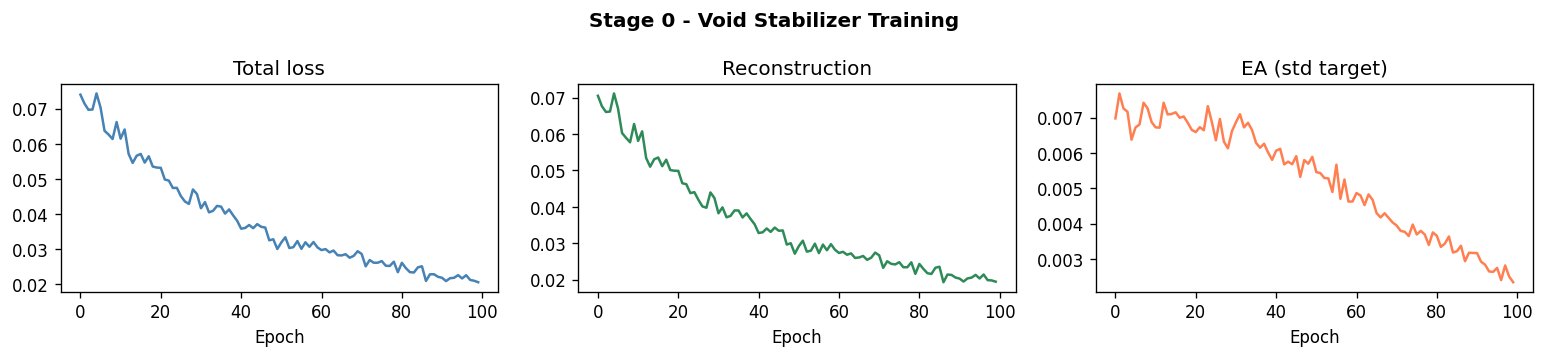

Saved: fulps_ca_v2_void_training.png


In [ ]:
# ── Cell 6: Stage 0 — Void Stabilization (unchanged from v1) ─────────────────
# Trained once; reused across all 30 runs. Independent of timestep count.
print('=' * 60)
print('STAGE 0: Void Stabilization')
print('=' * 60)

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

void_model = VoidStabilizer(
    seq_len=NBR_DIM, hidden_dim=VOID_HIDDEN,
    ea_target_std=EA_TARGET_STD, ea_weight=EA_WEIGHT
)

void_history = train_void_stabilizer(
    void_model, IDF, n_epochs=VOID_EPOCHS, batch_size=VOID_BATCH,
    lr=1e-3, verbose=True
)

for p in void_model.parameters():
    p.requires_grad = False
void_model.eval()

print('\nVoidStabilizer frozen. DSC + VT operational.')
print(f'  Final recon loss : {void_history["recon"][-1]:.4f}')
print(f'  Final EA loss    : {void_history["ea"][-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
fig.suptitle('Stage 0 - Void Stabilizer Training', fontweight='bold')
for ax, key, col, lbl in zip(
    axes,
    ['total', 'recon', 'ea'],
    ['steelblue', 'seagreen', 'coral'],
    ['Total loss', 'Reconstruction', 'EA (std target)']
):
    ax.plot(void_history[key], color=col)
    ax.set_title(lbl); ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulps_ca_v2_void_training.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fulps_ca_v2_void_training.png')

DSC THRESHOLD CALIBRATION
  IDF DSC   : mean=0.0199  std=0.0193
  CA  DSC   : mean=0.1291  std=0.0974
  DSC threshold (25th pct of CA) : 0.0526
  Separation: OK


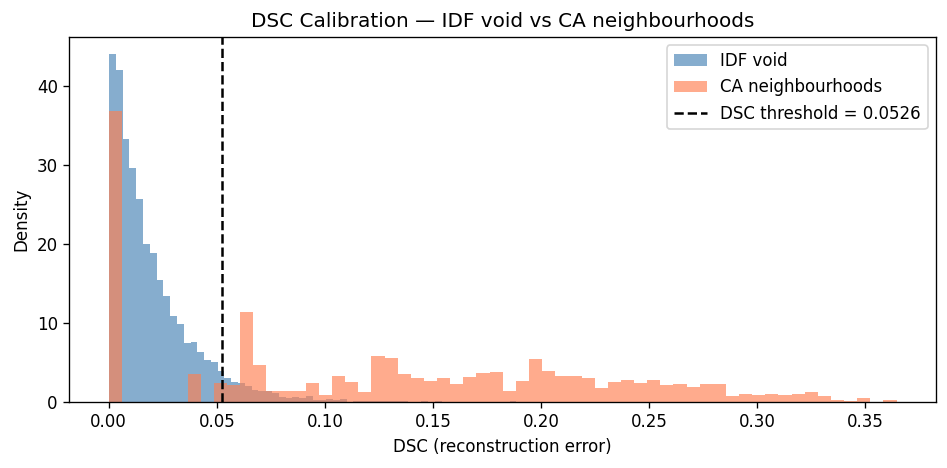

Saved: fulps_ca_v2_dsc_calibration.png


In [ ]:
# ── Cell 7: DSC Threshold Calibration (unchanged from v1) ────────────────────
print('=' * 60)
print('DSC THRESHOLD CALIBRATION')
print('=' * 60)

np.random.seed(0)
cal_grid = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
all_ca_dsc = []
_shifts_cal = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]

for _ in range(5):
    channels = np.zeros((GRID_H, GRID_W, 9), dtype=np.float32)
    for k, (di, dj) in enumerate(_shifts_cal):
        channels[:, :, k] = np.roll(
            np.roll(cal_grid, -di, axis=0), -dj, axis=1
        ).astype(np.float32)
    nbr_t = torch.FloatTensor(channels.reshape(-1, NBR_DIM))
    with torch.no_grad():
        dsc_vals = void_model.dsc(nbr_t).numpy()
    all_ca_dsc.append(dsc_vals)
    cal_grid = tick(cal_grid)

all_ca_dsc = np.concatenate(all_ca_dsc)
x_idf_ref  = IDF.sample_tensor(5000)
with torch.no_grad():
    idf_dsc_ref = void_model.dsc(x_idf_ref).numpy()

DSC_THRESHOLD = float(np.percentile(all_ca_dsc, 25))

print(f'  IDF DSC   : mean={idf_dsc_ref.mean():.4f}  std={idf_dsc_ref.std():.4f}')
print(f'  CA  DSC   : mean={all_ca_dsc.mean():.4f}  std={all_ca_dsc.std():.4f}')
print(f'  DSC threshold (25th pct of CA) : {DSC_THRESHOLD:.4f}')
separation_ok = idf_dsc_ref.mean() < all_ca_dsc.mean()
print(f'  Separation: {"OK" if separation_ok else "WARNING: no separation"}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(idf_dsc_ref, bins=60, alpha=0.65, color='steelblue', label='IDF void', density=True)
ax.hist(all_ca_dsc,  bins=60, alpha=0.65, color='coral',     label='CA neighbourhoods', density=True)
ax.axvline(DSC_THRESHOLD, color='black', linestyle='--', lw=1.5,
           label=f'DSC threshold = {DSC_THRESHOLD:.4f}')
ax.set_xlabel('DSC (reconstruction error)'); ax.set_ylabel('Density')
ax.set_title('DSC Calibration — IDF void vs CA neighbourhoods')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulps_ca_v2_dsc_calibration.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fulps_ca_v2_dsc_calibration.png')

In [ ]:
# ── Cell 8: Grid and Neighbourhood Utilities ──────────────────────────────────

def precompute_gol_truth():
    truth = np.zeros(N_STATES, dtype=np.int8)
    for state in range(N_STATES):
        bits   = np.array([(state >> k) & 1 for k in range(9)], dtype=np.int8)
        own    = int(bits[4])
        n_nbrs = int(bits.sum()) - own
        if own == 1:
            truth[state] = 1 if n_nbrs in [2, 3] else 0
        else:
            truth[state] = 1 if n_nbrs == 3 else 0
    return truth


GOL_TRUTH = precompute_gol_truth()
print(f'GoL truth: {GOL_TRUTH.sum()}/{N_STATES} survival states '
      f'({GOL_TRUTH.sum()/N_STATES*100:.1f}%) — confirms death-bias')

_II     = np.arange(GRID_H)[:, None] * np.ones(GRID_W, dtype=int)[None, :]
_JJ     = np.ones(GRID_H, dtype=int)[:, None] * np.arange(GRID_W)[None, :]
_POWERS = (2 ** np.arange(9)).astype(np.int32)
_SHIFTS = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]


def encode_neighbourhoods(grid):
    channels = np.zeros((GRID_H, GRID_W, 9), dtype=np.float32)
    for k, (di, dj) in enumerate(_SHIFTS):
        channels[:, :, k] = np.roll(
            np.roll(grid, -di, axis=0), -dj, axis=1
        ).astype(np.float32)
    indices = (channels.astype(np.int32) * _POWERS[None, None, :]).sum(axis=-1)
    return indices, channels


def predict_from_table(table, nbr_indices, contradiction_mask=None):
    """
    Confidence-threshold prediction.
    BASE_THRESHOLD=0.70 normally; CONTRA_THRESHOLD=0.60 for contradiction-flagged cells.
    """
    counts    = table[_II, _JJ, nbr_indices]          # [H, W, 2]
    total     = counts.sum(axis=-1)
    p_survive = counts[..., 1] / np.maximum(total, 1)
    threshold = np.full((GRID_H, GRID_W), BASE_THRESHOLD, dtype=np.float32)
    if contradiction_mask is not None:
        threshold = np.where(contradiction_mask, CONTRA_THRESHOLD, BASE_THRESHOLD)
    return (p_survive > threshold).astype(np.int8)


def table_accuracy_grid(table):
    probs   = table[..., 1] / np.maximum(table.sum(axis=-1), 1)
    preds   = (probs > BASE_THRESHOLD).astype(np.int8)
    correct = (preds == GOL_TRUTH[None, None, :])
    return correct.mean(axis=-1).astype(np.float32)


def table_coverage_grid(table):
    observed = (table.max(axis=-1) > 1.0)
    return observed.mean(axis=-1).astype(np.float32)


def per_state_accuracy_grid(table):
    observed = (table.max(axis=-1) > 1.0)
    probs    = table[..., 1] / np.maximum(table.sum(axis=-1), 1)
    preds    = (probs > BASE_THRESHOLD).astype(np.int8)
    correct  = (preds == GOL_TRUTH[None, None, :]) & observed
    n_obs    = observed.sum(axis=-1).astype(np.float32)
    return np.where(n_obs > 0,
                    correct.sum(axis=-1).astype(np.float32) / np.maximum(n_obs, 1),
                    np.nan).astype(np.float32)


def detect_stable_cells(state_history, max_changes=STABLE_MAX_CHANGES):
    n_changes = np.sum(
        np.abs(np.diff(state_history.astype(np.int16), axis=0)), axis=0
    )
    return (n_changes <= max_changes)


print('Grid utilities defined.')
print(f'  BASE_THRESHOLD={BASE_THRESHOLD}  CONTRA_THRESHOLD={CONTRA_THRESHOLD}')

GoL truth: 140/512 survival states (27.3%) — confirms death-bias
Grid utilities defined.
  BASE_THRESHOLD=0.7  CONTRA_THRESHOLD=0.6


In [ ]:
# ── Cell 9: FULPs State — Tables, ARE, and Convergence Tracking ──────────────

def init_tables():
    """Laplace-smoothed frequency tables. Shape: [H, W, 512, 2]."""
    return np.ones((GRID_H, GRID_W, N_STATES, 2), dtype=np.float32)


def init_are_state():
    """Per-cell dual-buffer EMA state for the ARE."""
    return {
        'pos_rep'    : np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
        'neg_rep'    : np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
        'pos_active' : np.zeros((GRID_H, GRID_W), dtype=bool),
        'neg_active' : np.zeros((GRID_H, GRID_W), dtype=bool),
    }


def init_convergence_state():
    """
    Convergence tracking arrays.
    conv_timestep: first t at which cell achieves correct+confident prediction
                   for its current state with >=2 prior observations.
                   Initialized to N_TIMESTEPS (= not converged).
    conv_locked  : True once convergence timestep is recorded.
    visit_counts : integer tally of times each state has been observed per cell.
    """
    return {
        'f_timestep'  : np.full((GRID_H, GRID_W), float(N_TIMESTEPS), dtype=np.float32),
        'b_timestep'  : np.full((GRID_H, GRID_W), float(N_TIMESTEPS), dtype=np.float32),
        'f_locked'    : np.zeros((GRID_H, GRID_W), dtype=bool),
        'b_locked'    : np.zeros((GRID_H, GRID_W), dtype=bool),
        'visit_counts': np.zeros((GRID_H, GRID_W, N_STATES), dtype=np.int32),
    }


def compute_are_margin(reps_flat, are_state, threshold):
    """
    ARE margin and contradiction flags (v2: CONF_GATE=0.60, ablation-confirmed).
    Contradiction fires when: |margin| < threshold AND max(pos_sim,neg_sim) > CONF_GATE
                              AND both buffers populated.
    """
    rep   = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    p_rep = are_state['pos_rep']
    n_rep = are_state['neg_rep']

    def cos_sim_hw(a, b):
        dot    = np.sum(a * b, axis=-1)
        norm_a = np.linalg.norm(a, axis=-1)
        norm_b = np.linalg.norm(b, axis=-1)
        denom  = np.where(norm_a * norm_b > 1e-8, norm_a * norm_b, 1e-8)
        return dot / denom

    pos_sim = np.where(are_state['pos_active'], cos_sim_hw(rep, p_rep), 0.0)
    neg_sim = np.where(are_state['neg_active'], cos_sim_hw(rep, n_rep), 0.0)

    margin      = pos_sim - neg_sim
    both_active = are_state['pos_active'] & are_state['neg_active']
    max_sim     = np.maximum(pos_sim, neg_sim)

    contra_flags = (
        (np.abs(margin) < threshold) &
        (max_sim > CONF_GATE) &
        both_active
    )
    return margin, contra_flags, pos_sim, neg_sim


def update_are_buffers(are_state, reps_flat, outcomes):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    mask_pos = (outcomes == 1)
    if mask_pos.any():
        are_state['pos_rep'][mask_pos] = (
            (1 - EMA_ALPHA) * are_state['pos_rep'][mask_pos] +
            EMA_ALPHA * rep[mask_pos]
        )
        are_state['pos_active'][mask_pos] = True
    mask_neg = (outcomes == 0)
    if mask_neg.any():
        are_state['neg_rep'][mask_neg] = (
            (1 - EMA_ALPHA) * are_state['neg_rep'][mask_neg] +
            EMA_ALPHA * rep[mask_neg]
        )
        are_state['neg_active'][mask_neg] = True


def update_tables(fulps_table, base_table, nbr_indices, outcomes, cw):
    outcome_int = outcomes.astype(int)
    fulps_table[_II, _JJ, nbr_indices, outcome_int] += cw
    base_table[ _II, _JJ, nbr_indices, outcome_int] += 1.0


def update_convergence(
    conv_state, t,
    fulps_table, base_table,
    nbr_indices, outcomes,
    active_contra
):
    """
    Convergence check after table update.

    A cell converges at timestep t when, for the state it is currently observing:
      (a) it has been observed >=2 times (beyond Laplace prior),
      (b) the prediction is correct,
      (c) confidence exceeds the appropriate threshold:
          - survival states (truth=1): p_survive > BASE_THRESHOLD
          - death states   (truth=0): p_survive < (1 - BASE_THRESHOLD)
          - FULPs contradiction cells use CONTRA_THRESHOLD instead of BASE_THRESHOLD

    GoL determinism guarantees monotonic table accumulation, so once a cell
    crosses the confidence threshold for a given state, it never reverses.
    Locking on first achievement is therefore exact, not approximate.
    """
    # Update visit counts
    conv_state['visit_counts'][_II, _JJ, nbr_indices] += 1
    visits_here = conv_state['visit_counts'][_II, _JJ, nbr_indices]   # [H, W]
    observed_twice = (visits_here >= 2)

    truth_here = GOL_TRUTH[nbr_indices]                                # [H, W]

    # ── FULPs convergence ─────────────────────────────────────────────────
    f_counts   = fulps_table[_II, _JJ, nbr_indices]                   # [H, W, 2]
    f_p        = f_counts[..., 1] / np.maximum(f_counts.sum(axis=-1), 1)
    f_thresh   = np.where(active_contra, CONTRA_THRESHOLD, BASE_THRESHOLD)
    f_correct  = ((f_p > f_thresh).astype(np.int8) == truth_here)
    f_confident = np.where(
        truth_here == 1,
        f_p > f_thresh,
        f_p < (1.0 - f_thresh)
    )
    newly_f = f_correct & f_confident & observed_twice & ~conv_state['f_locked']
    conv_state['f_timestep'][newly_f] = t
    conv_state['f_locked'][newly_f]   = True

    # ── Baseline convergence ──────────────────────────────────────────────
    b_counts   = base_table[_II, _JJ, nbr_indices]
    b_p        = b_counts[..., 1] / np.maximum(b_counts.sum(axis=-1), 1)
    b_correct  = ((b_p > BASE_THRESHOLD).astype(np.int8) == truth_here)
    b_confident = np.where(
        truth_here == 1,
        b_p > BASE_THRESHOLD,
        b_p < (1.0 - BASE_THRESHOLD)
    )
    newly_b = b_correct & b_confident & observed_twice & ~conv_state['b_locked']
    conv_state['b_timestep'][newly_b] = t
    conv_state['b_locked'][newly_b]   = True


print('FULPs state + convergence tracking utilities defined.')

FULPs state + convergence tracking utilities defined.


In [ ]:
# ── Cell 10: Simulation Engine ────────────────────────────────────────────────
def run_simulation(seed, void_model, idf, dsc_threshold,
                   is_single_run=False, verbose=False):
    """
    v2 simulation loop: 100 timesteps with convergence speed tracking.

    Per-timestep:
      1  Encode neighbourhoods
      2  GoL tick -> ground truth outcomes
      3  DSC + ARE representations
      4  Dynamic contradiction threshold
      5  ARE margin + contradiction flags (CONF_GATE=0.60)
      6  DSC gate + curiosity weights
      7  Predictions (FULPs: contradiction-aware threshold; baseline: uniform)
      8  Update tables
      9  Update ARE buffers (delayed until t>=BUFFER_DELAY)
     10  Convergence check (after table update)
     11  Log metrics
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    grid        = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    fulps_table = init_tables()
    base_table  = init_tables()
    are_state   = init_are_state()
    conv_state  = init_convergence_state()

    state_history  = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)
    contra_history = []

    history = {
        'fulps_online_acc': [], 'base_online_acc' : [],
        'fulps_table_acc' : [], 'base_table_acc'  : [],
        'fulps_coverage'  : [], 'base_coverage'   : [],
        'contra_rate'     : [], 'margin_mean'      : [],
        'vt_signal'       : [], 'population'       : [],
        'threshold'       : [],
        'fulps_conv_frac' : [], 'base_conv_frac'   : [],
    } if is_single_run else None

    for t in range(N_TIMESTEPS):
        state_history[t] = grid.copy()

        # ── 1. Encode ─────────────────────────────────────────────────────
        nbr_indices, nbr_floats = encode_neighbourhoods(grid)
        nbr_tensor = torch.FloatTensor(nbr_floats.reshape(-1, NBR_DIM))

        # ── 2. Tick ───────────────────────────────────────────────────────
        next_grid = tick(grid)
        outcomes  = next_grid.astype(np.int8)

        # ── 3. DSC + representations ──────────────────────────────────────
        with torch.no_grad():
            dsc_vals  = void_model.dsc(nbr_tensor).numpy().reshape(GRID_H, GRID_W)
            reps_flat = void_model.encode(nbr_tensor).numpy()

        # ── 4. Dynamic threshold ──────────────────────────────────────────
        progress  = t / max(N_TIMESTEPS - 1, 1)
        threshold = CONTRA_START + (CONTRA_END - CONTRA_START) * progress

        # ── 5. ARE margin + contradiction ─────────────────────────────────
        margin, contra_flags, _, _ = compute_are_margin(
            reps_flat, are_state, threshold
        )
        contra_history.append(float(contra_flags.mean()))

        # ── 6. DSC gate + curiosity weights ──────────────────────────────
        dsc_gate     = (dsc_vals > dsc_threshold)
        active_contra = contra_flags & dsc_gate
        cw            = np.ones((GRID_H, GRID_W), dtype=np.float32)
        cw[active_contra] = CURIOSITY_WEIGHT

        # ── 7. Predictions ────────────────────────────────────────────────
        fulps_preds = predict_from_table(fulps_table, nbr_indices, active_contra)
        base_preds  = predict_from_table(base_table,  nbr_indices, None)

        # ── 8. Update tables ──────────────────────────────────────────────
        update_tables(fulps_table, base_table, nbr_indices, outcomes, cw)

        # ── 9. Update ARE buffers (delayed) ──────────────────────────────
        if t >= BUFFER_DELAY:
            update_are_buffers(are_state, reps_flat, outcomes)

        # ── 10. Convergence check (after table update) ────────────────────
        update_convergence(
            conv_state, t,
            fulps_table, base_table,
            nbr_indices, outcomes,
            active_contra
        )

        # ── 11. Metrics ───────────────────────────────────────────────────
        if is_single_run:
            f_online = float(np.mean(fulps_preds == outcomes))
            b_online = float(np.mean(base_preds  == outcomes))
            f_tacc   = float(table_accuracy_grid(fulps_table).mean())
            b_tacc   = float(table_accuracy_grid(base_table).mean())
            f_cov    = float(table_coverage_grid(fulps_table).mean())
            b_cov    = float(table_coverage_grid(base_table).mean())
            vt_sig   = void_model.void_tether(idf, n=64)
            f_cf     = float(conv_state['f_locked'].mean())
            b_cf     = float(conv_state['b_locked'].mean())

            history['fulps_online_acc'].append(f_online)
            history['base_online_acc'].append(b_online)
            history['fulps_table_acc'].append(f_tacc)
            history['base_table_acc'].append(b_tacc)
            history['fulps_coverage'].append(f_cov)
            history['base_coverage'].append(b_cov)
            history['contra_rate'].append(float(contra_flags.mean()))
            history['margin_mean'].append(float(margin.mean()))
            history['vt_signal'].append(vt_sig)
            history['population'].append(population(grid))
            history['threshold'].append(threshold)
            history['fulps_conv_frac'].append(f_cf)
            history['base_conv_frac'].append(b_cf)

            if verbose and t % 10 == 0:
                print(f'  [t={t:3d}]  pop={population(grid):4d}  '
                      f'f_online={f_online:.3f}  b_online={b_online:.3f}  '
                      f'f_tacc={f_tacc:.3f}  b_tacc={b_tacc:.3f}  '
                      f'cov={f_cov:.3f}  contra={contra_flags.mean():.3f}  '
                      f'conv_f={f_cf:.3f}  conv_b={b_cf:.3f}  '
                      f'VT={vt_sig:.4f}')

        grid = next_grid

    # ── Post-simulation summaries ──────────────────────────────────────────
    stable_mask   = detect_stable_cells(state_history)
    unstable_mask = ~stable_mask

    f_tacc_g = table_accuracy_grid(fulps_table)
    b_tacc_g = table_accuracy_grid(base_table)
    f_cov_g  = table_coverage_grid(fulps_table)
    b_cov_g  = table_coverage_grid(base_table)
    f_ps_g   = per_state_accuracy_grid(fulps_table)
    b_ps_g   = per_state_accuracy_grid(base_table)

    f_conv_g = conv_state['f_timestep']   # [H, W]
    b_conv_g = conv_state['b_timestep']

    def region_mean(arr, mask):
        if not mask.any(): return np.nan
        vals = arr[mask]
        vals = vals[~np.isnan(vals)]
        return float(vals.mean()) if len(vals) > 0 else np.nan

    results = {
        # ── Accuracy ───────────────────────────────────────────────────
        'fulps_final_table_acc'     : float(f_tacc_g.mean()),
        'base_final_table_acc'      : float(b_tacc_g.mean()),
        'fulps_final_perstate'      : float(np.nanmean(f_ps_g)),
        'base_final_perstate'       : float(np.nanmean(b_ps_g)),
        'fulps_stable_tacc'         : region_mean(f_tacc_g, stable_mask),
        'base_stable_tacc'          : region_mean(b_tacc_g, stable_mask),
        'fulps_unstable_tacc'       : region_mean(f_tacc_g, unstable_mask),
        'base_unstable_tacc'        : region_mean(b_tacc_g, unstable_mask),
        # ── Coverage ────────────────────────────────────────────────────
        'fulps_final_coverage'      : float(f_cov_g.mean()),
        'base_final_coverage'       : float(b_cov_g.mean()),
        'fulps_stable_coverage'     : region_mean(f_cov_g, stable_mask),
        'base_stable_coverage'      : region_mean(b_cov_g, stable_mask),
        'fulps_unstable_coverage'   : region_mean(f_cov_g, unstable_mask),
        'base_unstable_coverage'    : region_mean(b_cov_g, unstable_mask),
        # ── Convergence speed (primary v2 metric) ───────────────────────
        'fulps_mean_conv_t'         : float(f_conv_g.mean()),
        'base_mean_conv_t'          : float(b_conv_g.mean()),
        'fulps_stable_conv_t'       : region_mean(f_conv_g, stable_mask),
        'base_stable_conv_t'        : region_mean(b_conv_g, stable_mask),
        'fulps_unstable_conv_t'     : region_mean(f_conv_g, unstable_mask),
        'base_unstable_conv_t'      : region_mean(b_conv_g, unstable_mask),
        'fulps_conv_fraction'       : float(conv_state['f_locked'].mean()),
        'base_conv_fraction'        : float(conv_state['b_locked'].mean()),
        # ── Summary ─────────────────────────────────────────────────────
        'stable_fraction'           : float(stable_mask.mean()),
        'mean_contra_rate'          : float(np.mean(contra_history)),
    }

    final_state = None
    if is_single_run:
        final_state = {
            'grid'         : grid,
            'state_history': state_history,
            'stable_mask'  : stable_mask,
            'f_tacc_g'     : f_tacc_g,
            'b_tacc_g'     : b_tacc_g,
            'f_cov_g'      : f_cov_g,
            'b_cov_g'      : b_cov_g,
            'f_ps_g'       : f_ps_g,
            'b_ps_g'       : b_ps_g,
            'f_conv_g'     : f_conv_g,
            'b_conv_g'     : b_conv_g,
        }

    return history, results, final_state


print('Simulation engine defined (v2: 100 timesteps, convergence tracking).')

Simulation engine defined (v2: 100 timesteps, convergence tracking).


In [ ]:
# ── Cell 11: Single-Run Validation ───────────────────────────────────────────
# Run this cell FIRST. Confirm all health checks pass before the 30-run study.
#
# Health checks (v2):
#   1. DSC threshold non-trivial
#   2. Final online accuracy > 0.70 (both systems)
#   3. Table accuracy trends upward over 100 timesteps
#   4. Contradiction rate near 0 at t=0 (buffer delay respected)
#   5. Contradiction rate non-zero before t=20 (ARE active in extended run)
#   6. FULPs convergence fraction > baseline convergence fraction (primary result)
#   7. FULPs mean convergence timestep < baseline (faster convergence)
#   8. VT signal stable (void calibration held across 100 timesteps)
print('=' * 60)
print('SINGLE-RUN VALIDATION (seed=42)')
print('=' * 60)
print('Verbose output every 10 timesteps.\n')

single_history, single_results, single_final = run_simulation(
    seed=BASE_SEED,
    void_model=void_model,
    idf=IDF,
    dsc_threshold=DSC_THRESHOLD,
    is_single_run=True,
    verbose=True,
)

print('\n── Single-Run Results ─────────────────────────────────────')
for k, v in single_results.items():
    if isinstance(v, float) and np.isnan(v):
        print(f'  {k:<32} : N/A')
    else:
        print(f'  {k:<32} : {v:.4f}')

print('\n── Health Checks ──────────────────────────────────────────')
checks = [
    ('DSC threshold non-trivial',
     DSC_THRESHOLD > 0.001),
    ('Final online acc > 0.70 (FULPs)',
     single_history['fulps_online_acc'][-1] > 0.70),
    ('Final online acc > 0.70 (base)',
     single_history['base_online_acc'][-1] > 0.70),
    ('Table acc trends upward',
     single_history['fulps_table_acc'][-1] > single_history['fulps_table_acc'][0]),
    ('Contra rate = 0 at t=0 (buffer delay)',
     single_history['contra_rate'][0] < 0.001),
    ('Contra rate non-zero before t=20',
     any(r > 0.001 for r in single_history['contra_rate'][:20])),
    ('FULPs conv fraction > baseline',
     single_results['fulps_conv_fraction'] > single_results['base_conv_fraction']),
    ('FULPs mean conv_t < baseline',
     single_results['fulps_mean_conv_t'] < single_results['base_mean_conv_t']),
    ('VT signal stable (std < 0.01)',
     np.std(single_history['vt_signal']) < 0.01),
    ('Coverage reached > 5% by t=99',
     single_history['fulps_coverage'][-1] > 0.05),
]
for label, passed in checks:
    print(f'  [{"PASS" if passed else "FAIL"}]  {label}')

SINGLE-RUN VALIDATION (seed=42)
Verbose output every 10 timesteps.

  [t=  0]  pop=1303  f_online=0.742  b_online=0.742  f_tacc=0.727  b_tacc=0.727  cov=0.002  contra=0.000  conv_f=0.000  conv_b=0.000  VT=0.0183
  [t= 10]  pop= 463  f_online=0.840  b_online=0.840  f_tacc=0.727  b_tacc=0.727  cov=0.015  contra=0.000  conv_f=0.799  conv_b=0.799  VT=0.0174
  [t= 20]  pop= 376  f_online=0.864  b_online=0.857  f_tacc=0.728  b_tacc=0.727  cov=0.023  contra=0.307  conv_f=0.978  conv_b=0.978  VT=0.0176
  [t= 30]  pop= 269  f_online=0.917  b_online=0.909  f_tacc=0.730  b_tacc=0.727  cov=0.030  contra=0.301  conv_f=0.996  conv_b=0.996  VT=0.0193
  [t= 40]  pop= 274  f_online=0.902  b_online=0.895  f_tacc=0.731  b_tacc=0.727  cov=0.035  contra=0.268  conv_f=1.000  conv_b=1.000  VT=0.0160
  [t= 50]  pop= 252  f_online=0.922  b_online=0.910  f_tacc=0.733  b_tacc=0.728  cov=0.039  contra=0.226  conv_f=1.000  conv_b=1.000  VT=0.0153
  [t= 60]  pop= 299  f_online=0.906  b_online=0.898  f_tacc=0.734  b

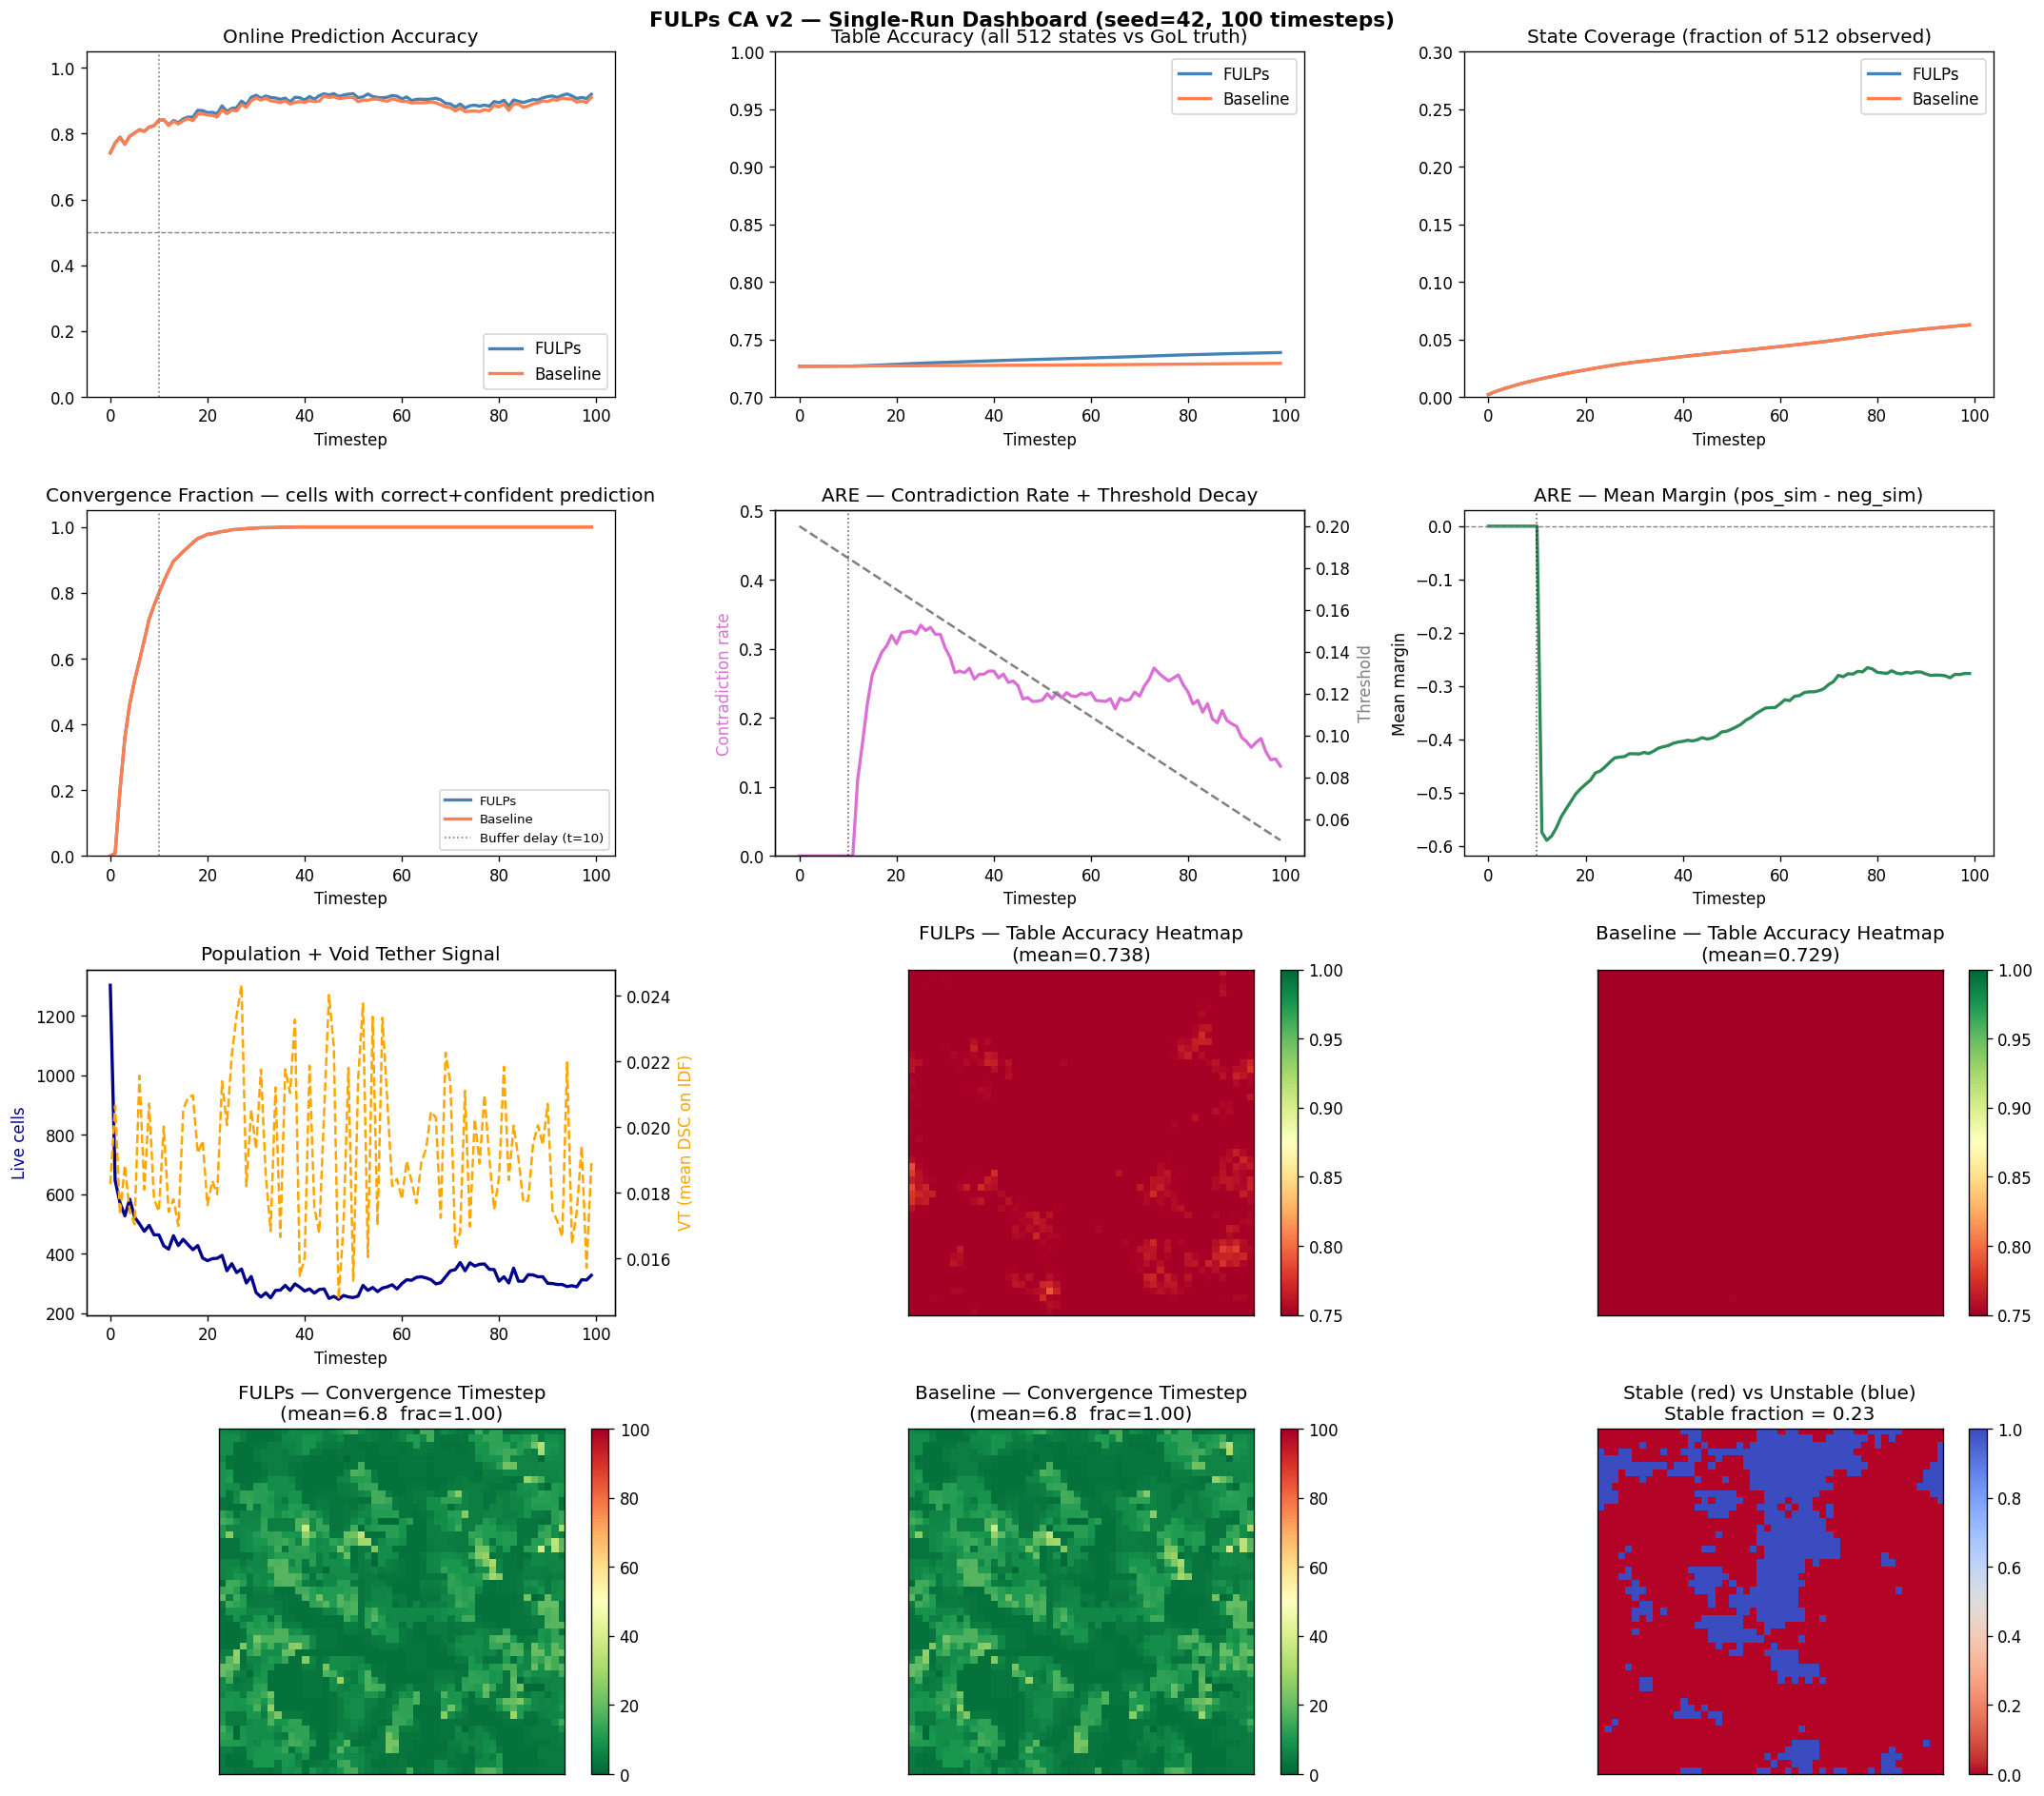

Saved: /content/fulps_ca_v2_single_run.png


In [ ]:
# ── Cell 12: Single-Run Dashboard (4×3 layout) ───────────────────────────────
fig = plt.figure(figsize=(18, 16))
fig.suptitle('FULPs CA v2 — Single-Run Dashboard (seed=42, 100 timesteps)',
             fontsize=13, fontweight='bold')

T = list(range(N_TIMESTEPS))

# ── Row 1: Accuracy and Coverage ──────────────────────────────────────────────
ax1 = fig.add_subplot(4, 3, 1)
ax1.plot(T, single_history['fulps_online_acc'], color='steelblue', label='FULPs', lw=2)
ax1.plot(T, single_history['base_online_acc'],  color='coral',     label='Baseline', lw=2)
ax1.axvline(BUFFER_DELAY, color='gray', linestyle=':', lw=1)
ax1.set_title('Online Prediction Accuracy'); ax1.set_xlabel('Timestep')
ax1.set_ylim(0, 1.05); ax1.legend()
ax1.axhline(0.5, color='gray', linestyle='--', lw=0.8)

ax2 = fig.add_subplot(4, 3, 2)
ax2.plot(T, single_history['fulps_table_acc'], color='steelblue', label='FULPs', lw=2)
ax2.plot(T, single_history['base_table_acc'],  color='coral',     label='Baseline', lw=2)
ax2.set_title('Table Accuracy (all 512 states vs GoL truth)')
ax2.set_xlabel('Timestep'); ax2.set_ylim(0.7, 1.0); ax2.legend()

ax3 = fig.add_subplot(4, 3, 3)
ax3.plot(T, single_history['fulps_coverage'], color='steelblue', label='FULPs', lw=2)
ax3.plot(T, single_history['base_coverage'],  color='coral',     label='Baseline', lw=2)
ax3.set_title('State Coverage (fraction of 512 observed)')
ax3.set_xlabel('Timestep'); ax3.set_ylim(0, 0.3); ax3.legend()

# ── Row 2: Convergence Speed ──────────────────────────────────────────────────
ax4 = fig.add_subplot(4, 3, 4)
ax4.plot(T, single_history['fulps_conv_frac'], color='steelblue', label='FULPs', lw=2)
ax4.plot(T, single_history['base_conv_frac'],  color='coral',     label='Baseline', lw=2)
ax4.axvline(BUFFER_DELAY, color='gray', linestyle=':', lw=1,
            label=f'Buffer delay (t={BUFFER_DELAY})')
ax4.set_title('Convergence Fraction — cells with correct+confident prediction')
ax4.set_xlabel('Timestep'); ax4.set_ylim(0, 1.05); ax4.legend(fontsize=8)

ax5 = fig.add_subplot(4, 3, 5)
ax5b = ax5.twinx()
ax5.plot(T, single_history['contra_rate'], color='orchid', lw=2, label='Contra rate')
ax5b.plot(T, single_history['threshold'], color='gray', linestyle='--', lw=1.5,
          label='Threshold')
ax5.axvline(BUFFER_DELAY, color='black', linestyle=':', lw=1, alpha=0.6)
ax5.set_title('ARE — Contradiction Rate + Threshold Decay')
ax5.set_xlabel('Timestep')
ax5.set_ylabel('Contradiction rate', color='orchid')
ax5b.set_ylabel('Threshold', color='gray')
ax5.set_ylim(0, 0.5)

ax6 = fig.add_subplot(4, 3, 6)
ax6.plot(T, single_history['margin_mean'], color='seagreen', lw=2)
ax6.axhline(0, color='gray', linestyle='--', lw=0.8)
ax6.axvline(BUFFER_DELAY, color='black', linestyle=':', lw=1, alpha=0.6)
ax6.set_title('ARE — Mean Margin (pos_sim - neg_sim)')
ax6.set_xlabel('Timestep'); ax6.set_ylabel('Mean margin')

# ── Row 3: Population and VT ──────────────────────────────────────────────────
ax7 = fig.add_subplot(4, 3, 7)
ax7b = ax7.twinx()
ax7.plot(T, single_history['population'], color='darkblue', lw=2, label='Population')
ax7b.plot(T, single_history['vt_signal'], color='orange', linestyle='--', lw=1.5,
          label='VT signal')
ax7.set_title('Population + Void Tether Signal')
ax7.set_xlabel('Timestep')
ax7.set_ylabel('Live cells', color='darkblue')
ax7b.set_ylabel('VT (mean DSC on IDF)', color='orange')

ax8 = fig.add_subplot(4, 3, 8)
im8 = ax8.imshow(single_final['f_tacc_g'], cmap='RdYlGn', vmin=0.75, vmax=1.0)
ax8.set_title(f'FULPs — Table Accuracy Heatmap\n(mean={single_results["fulps_final_table_acc"]:.3f})')
plt.colorbar(im8, ax=ax8, fraction=0.046)
ax8.set_xticks([]); ax8.set_yticks([])

ax9 = fig.add_subplot(4, 3, 9)
im9 = ax9.imshow(single_final['b_tacc_g'], cmap='RdYlGn', vmin=0.75, vmax=1.0)
ax9.set_title(f'Baseline — Table Accuracy Heatmap\n(mean={single_results["base_final_table_acc"]:.3f})')
plt.colorbar(im9, ax=ax9, fraction=0.046)
ax9.set_xticks([]); ax9.set_yticks([])

# ── Row 4: Convergence Heatmaps and Stability ─────────────────────────────────
ax10 = fig.add_subplot(4, 3, 10)
im10 = ax10.imshow(single_final['f_conv_g'], cmap='RdYlGn_r',
                   vmin=0, vmax=N_TIMESTEPS)
ax10.set_title(f'FULPs — Convergence Timestep\n'
               f'(mean={single_results["fulps_mean_conv_t"]:.1f}  '
               f'frac={single_results["fulps_conv_fraction"]:.2f})')
plt.colorbar(im10, ax=ax10, fraction=0.046)
ax10.set_xticks([]); ax10.set_yticks([])

ax11 = fig.add_subplot(4, 3, 11)
im11 = ax11.imshow(single_final['b_conv_g'], cmap='RdYlGn_r',
                   vmin=0, vmax=N_TIMESTEPS)
ax11.set_title(f'Baseline — Convergence Timestep\n'
               f'(mean={single_results["base_mean_conv_t"]:.1f}  '
               f'frac={single_results["base_conv_fraction"]:.2f})')
plt.colorbar(im11, ax=ax11, fraction=0.046)
ax11.set_xticks([]); ax11.set_yticks([])

ax12 = fig.add_subplot(4, 3, 12)
im12 = ax12.imshow(single_final['stable_mask'].astype(float),
                   cmap='coolwarm_r', vmin=0, vmax=1)
ax12.set_title(f'Stable (red) vs Unstable (blue)\n'
               f'Stable fraction = {single_results["stable_fraction"]:.2f}')
plt.colorbar(im12, ax=ax12, fraction=0.046)
ax12.set_xticks([]); ax12.set_yticks([])

plt.tight_layout()
path = os.path.join(OUT_DIR, 'fulps_ca_v2_single_run.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [ ]:
# ── Cell 13: Multi-Run Study (30 runs) ───────────────────────────────────────
# Confirm all single-run health checks PASS before running this cell.
# Batch CSVs save every 5 runs. Download from Colab file panel as they appear.
print('=' * 60)
print('STARTING 30-RUN STUDY (v2 — 100 timesteps)')
print('=' * 60)
print(f'Seeds: {BASE_SEED}–{BASE_SEED+N_RUNS-1}  |  Batch CSVs every {BATCH_SIZE} runs\n')

METRIC_KEYS = [
    # Accuracy
    'fulps_final_table_acc',   'base_final_table_acc',
    'fulps_final_perstate',    'base_final_perstate',
    'fulps_stable_tacc',       'base_stable_tacc',
    'fulps_unstable_tacc',     'base_unstable_tacc',
    # Coverage
    'fulps_final_coverage',    'base_final_coverage',
    'fulps_stable_coverage',   'base_stable_coverage',
    'fulps_unstable_coverage', 'base_unstable_coverage',
    # Convergence speed (primary v2 metrics)
    'fulps_mean_conv_t',       'base_mean_conv_t',
    'fulps_stable_conv_t',     'base_stable_conv_t',
    'fulps_unstable_conv_t',   'base_unstable_conv_t',
    'fulps_conv_fraction',     'base_conv_fraction',
    # Summary
    'stable_fraction',         'mean_contra_rate',
]

all_results = {k: [] for k in METRIC_KEYS}
all_rows    = []

for run_idx in range(N_RUNS):
    seed = BASE_SEED + run_idx
    print(f'Run {run_idx+1:2d}/{N_RUNS}  (seed={seed})', end=' ... ')

    _, results, _ = run_simulation(
        seed=seed,
        void_model=void_model,
        idf=IDF,
        dsc_threshold=DSC_THRESHOLD,
        is_single_run=False,
        verbose=False,
    )

    for k in METRIC_KEYS:
        all_results[k].append(results.get(k, np.nan))

    row = {'run': run_idx + 1, 'seed': seed}
    row.update(results)
    all_rows.append(row)

    if (run_idx + 1) % BATCH_SIZE == 0:
        batch_num  = (run_idx + 1) // BATCH_SIZE
        batch_df   = pd.DataFrame(all_rows[-BATCH_SIZE:])
        batch_path = os.path.join(OUT_DIR, f'results_v2_batch_{batch_num}.csv')
        batch_df.to_csv(batch_path, index=False)
        f_ct = np.nanmean(all_results['fulps_mean_conv_t'][-BATCH_SIZE:])
        b_ct = np.nanmean(all_results['base_mean_conv_t'][-BATCH_SIZE:])
        print(f'\n  Batch {batch_num} saved -> {batch_path}')
        print(f'  Batch mean  fulps_conv_t={f_ct:.1f}  base_conv_t={b_ct:.1f}')
    else:
        f_ct = results['fulps_mean_conv_t']
        b_ct = results['base_mean_conv_t']
        print(f'fulps_conv_t={f_ct:.1f}  base_conv_t={b_ct:.1f}')

full_df   = pd.DataFrame(all_rows)
full_path = os.path.join(OUT_DIR, 'results_30runs_ca_v2.csv')
full_df.to_csv(full_path, index=False)
print(f'\nFull CSV saved -> {full_path}')
print('Download from the Colab file panel.')

STARTING 30-RUN STUDY (v2 — 100 timesteps)
Seeds: 42–71  |  Batch CSVs every 5 runs

Run  1/30  (seed=42) ... fulps_conv_t=6.8  base_conv_t=6.8
Run  2/30  (seed=43) ... fulps_conv_t=7.7  base_conv_t=7.7
Run  3/30  (seed=44) ... fulps_conv_t=7.3  base_conv_t=7.3
Run  4/30  (seed=45) ... fulps_conv_t=7.9  base_conv_t=7.9
Run  5/30  (seed=46) ... 
  Batch 1 saved -> /content/results_v2_batch_1.csv
  Batch mean  fulps_conv_t=7.5  base_conv_t=7.5
Run  6/30  (seed=47) ... fulps_conv_t=7.7  base_conv_t=7.7
Run  7/30  (seed=48) ... fulps_conv_t=8.0  base_conv_t=8.0
Run  8/30  (seed=49) ... fulps_conv_t=7.2  base_conv_t=7.2
Run  9/30  (seed=50) ... fulps_conv_t=6.8  base_conv_t=6.8
Run 10/30  (seed=51) ... 
  Batch 2 saved -> /content/results_v2_batch_2.csv
  Batch mean  fulps_conv_t=7.4  base_conv_t=7.4
Run 11/30  (seed=52) ... fulps_conv_t=7.3  base_conv_t=7.3
Run 12/30  (seed=53) ... fulps_conv_t=7.6  base_conv_t=7.6
Run 13/30  (seed=54) ... fulps_conv_t=7.4  base_conv_t=7.4
Run 14/30  (seed

In [ ]:
# ── Cell 14: Statistical Summary ─────────────────────────────────────────────
print('=' * 60)
print('30-RUN STATISTICAL SUMMARY — FULPs CA v2')
print('=' * 60)


def summarise(key):
    a = np.array([v for v in all_results[key] if not np.isnan(v)])
    if len(a) == 0: return np.nan, np.nan, np.nan
    ci = 1.96 * a.std() / np.sqrt(len(a))
    return a.mean(), a.std(), ci


def safe_arr(key):
    return np.array([v for v in all_results[key] if not np.isnan(v)])


def cohens_d(a, b):
    pooled = np.sqrt((a.std() ** 2 + b.std() ** 2) / 2)
    return (a.mean() - b.mean()) / pooled if pooled > 1e-9 else np.nan


print(f"\n  {'Metric':<36} {'Mean':>7} {'SD':>7} {'95% CI':>10}")
print('  ' + '-' * 64)
for k in METRIC_KEYS:
    m, s, ci = summarise(k)
    if not np.isnan(m):
        print(f'  {k:<36} {m:>7.3f} {s:>7.3f}  +-{ci:>6.3f}')


print('\n── PRIMARY HYPOTHESIS TESTS ───────────────────────────────')

# PRIMARY: FULPs converges faster than baseline (paired t-test)
f_ct = safe_arr('fulps_mean_conv_t')
b_ct = safe_arr('base_mean_conv_t')
if len(f_ct) > 2 and len(b_ct) > 2:
    t_ct, p_ct = stats.ttest_rel(f_ct, b_ct)
    d_ct = cohens_d(f_ct, b_ct)
    print(f'\n  PRIMARY — FULPs vs Baseline convergence timestep (paired)')
    print(f'    FULPs mean={f_ct.mean():.2f}  Baseline mean={b_ct.mean():.2f}')
    print(f'    t={t_ct:.3f}  p={p_ct:.4f}  Cohen d={d_ct:.3f}')
    wins = (safe_arr('fulps_mean_conv_t') < safe_arr('base_mean_conv_t')).sum()
    print(f'    FULPs faster in {wins}/30 runs')
    interp = 'SUPPORTED' if p_ct < 0.05 and f_ct.mean() < b_ct.mean() else 'NOT SUPPORTED'
    print(f'    -> {interp}')

# Hyp A: Stable cells converge faster than unstable (FULPs)
f_sc = safe_arr('fulps_stable_conv_t')
f_uc = safe_arr('fulps_unstable_conv_t')
if len(f_sc) > 2 and len(f_uc) > 2:
    t_a, p_a = stats.ttest_ind(f_sc, f_uc)
    d_a = cohens_d(f_sc, f_uc)
    print(f'\n  Hyp A — Stable vs Unstable convergence speed (FULPs)')
    print(f'    stable mean={f_sc.mean():.2f}  unstable mean={f_uc.mean():.2f}')
    print(f'    t={t_a:.3f}  p={p_a:.4f}  Cohen d={d_a:.3f}')
    interp = 'SUPPORTED' if p_a < 0.05 and f_sc.mean() < f_uc.mean() else 'NOT SUPPORTED'
    print(f'    -> {interp}')

# Hyp B: Stable cells have higher table accuracy (FULPs)
f_st = safe_arr('fulps_stable_tacc')
f_ut = safe_arr('fulps_unstable_tacc')
if len(f_st) > 2 and len(f_ut) > 2:
    t_b, p_b = stats.ttest_ind(f_st, f_ut)
    d_b = cohens_d(f_st, f_ut)
    print(f'\n  Hyp B — Stable vs Unstable table accuracy (FULPs)')
    print(f'    stable mean={f_st.mean():.3f}  unstable mean={f_ut.mean():.3f}')
    print(f'    t={t_b:.3f}  p={p_b:.4f}  Cohen d={d_b:.3f}')

# Hyp C (coverage): unstable cells cover more states
f_scov = safe_arr('fulps_stable_coverage')
f_ucov = safe_arr('fulps_unstable_coverage')
if len(f_scov) > 2 and len(f_ucov) > 2:
    t_cov, p_cov = stats.ttest_ind(f_ucov, f_scov)
    d_cov = cohens_d(f_ucov, f_scov)
    print(f'\n  Hyp C (coverage) — Unstable > Stable coverage (FULPs)')
    print(f'    unstable cov={f_ucov.mean():.3f}  stable cov={f_scov.mean():.3f}')
    print(f'    t={t_cov:.3f}  p={p_cov:.4f}  Cohen d={d_cov:.3f}')
    interp = 'SUPPORTED' if p_cov < 0.05 and f_ucov.mean() > f_scov.mean() else 'NOT SUPPORTED'
    print(f'    -> {interp}')

# Hyp C (per-state): FULPs attenuates unstable accuracy penalty vs baseline
f_ups = safe_arr('fulps_unstable_tacc')
b_ups = safe_arr('base_unstable_tacc')
if len(f_ups) > 2 and len(b_ups) > 2:
    t_ps, p_ps = stats.ttest_ind(f_ups, b_ups)
    d_ps = cohens_d(f_ups, b_ups)
    print(f'\n  Hyp C (per-state) — FULPs vs Baseline in unstable cells')
    print(f'    FULPs mean={f_ups.mean():.3f}  Baseline mean={b_ups.mean():.3f}')
    print(f'    t={t_ps:.3f}  p={p_ps:.4f}  Cohen d={d_ps:.3f}')

# Overall table accuracy
f_tacc = safe_arr('fulps_final_table_acc')
b_tacc = safe_arr('base_final_table_acc')
if len(f_tacc) > 2:
    t_main, p_main = stats.ttest_rel(f_tacc, b_tacc)
    d_main = cohens_d(f_tacc, b_tacc)
    print(f'\n  Overall table accuracy — FULPs vs Baseline')
    print(f'    FULPs mean={f_tacc.mean():.4f}  Baseline mean={b_tacc.mean():.4f}')
    print(f'    t={t_main:.3f}  p={p_main:.4f}  Cohen d={d_main:.3f}')
    wins = (f_tacc > b_tacc).sum()
    print(f'    FULPs wins: {wins}/30')

30-RUN STATISTICAL SUMMARY — FULPs CA v2

  Metric                                  Mean      SD     95% CI
  ----------------------------------------------------------------
  fulps_final_table_acc                  0.738   0.002  +- 0.001
  base_final_table_acc                   0.729   0.000  +- 0.000
  fulps_final_perstate                   0.841   0.006  +- 0.002
  base_final_perstate                    0.723   0.011  +- 0.004
  fulps_stable_tacc                      0.728   0.000  +- 0.000
  base_stable_tacc                       0.727   0.000  +- 0.000
  fulps_unstable_tacc                    0.741   0.001  +- 0.000
  base_unstable_tacc                     0.730   0.000  +- 0.000
  fulps_final_coverage                   0.060   0.007  +- 0.002
  base_final_coverage                    0.060   0.007  +- 0.002
  fulps_stable_coverage                  0.026   0.002  +- 0.001
  base_stable_coverage                   0.026   0.002  +- 0.001
  fulps_unstable_coverage                0.07

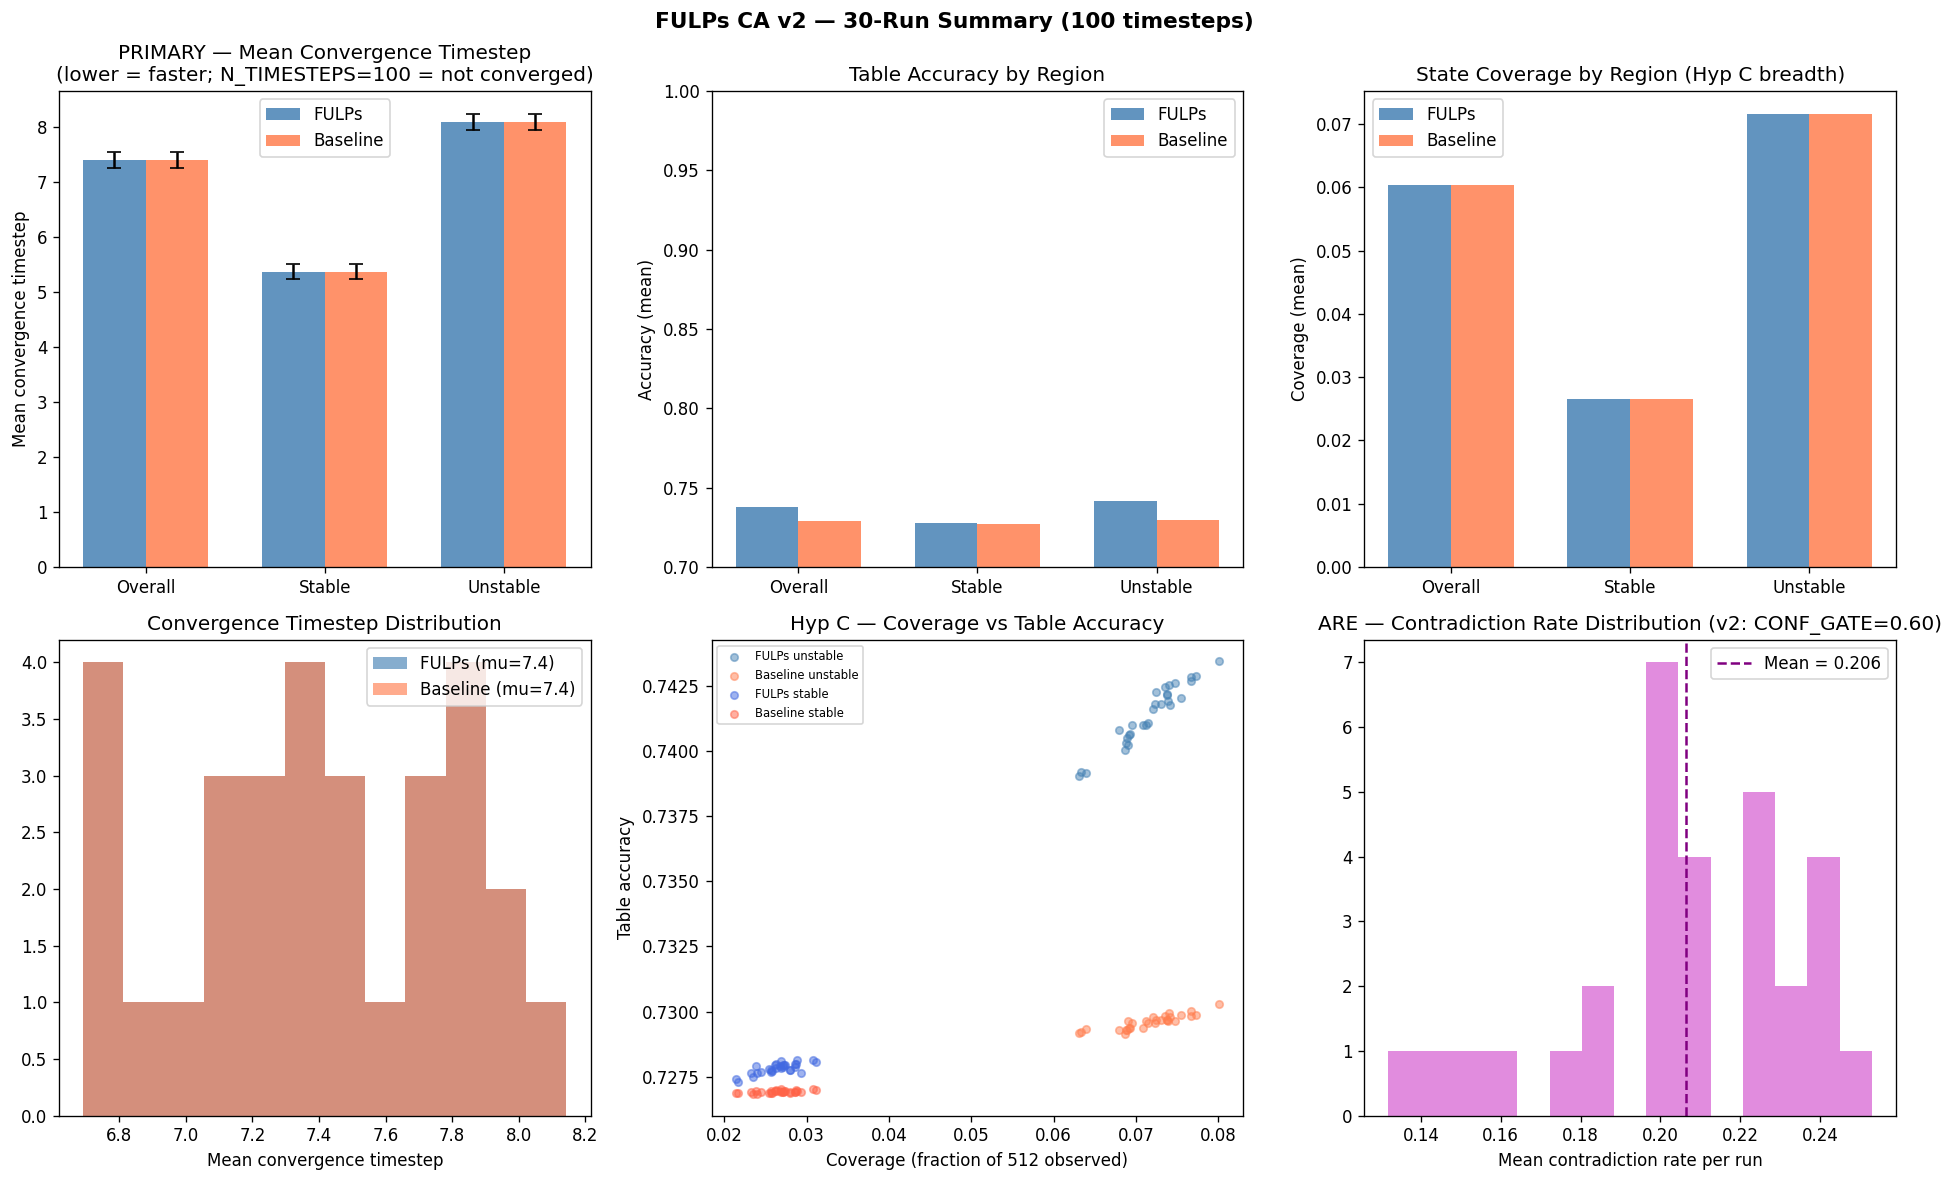

Multi-run chart saved -> /content/fulps_ca_v2_multirun.png
Full CSV              -> /content/results_30runs_ca_v2.csv
Download both from the Colab file panel.


In [ ]:
# ── Cell 15: Multi-Run Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('FULPs CA v2 — 30-Run Summary (100 timesteps)',
             fontsize=13, fontweight='bold')

def safe_mean(key):  return np.nanmean(all_results[key])
def safe_ci(key):    return 1.96 * np.nanstd(all_results[key]) / np.sqrt(N_RUNS)
def safe_arr_v(key): return np.array([v for v in all_results[key] if not np.isnan(v)])

# ── Convergence timestep by region (primary result) ───────────────────────────
ax = axes[0, 0]
cats  = ['Overall', 'Stable', 'Unstable']
f_ct  = [safe_mean('fulps_mean_conv_t'),    safe_mean('fulps_stable_conv_t'),
         safe_mean('fulps_unstable_conv_t')]
b_ct  = [safe_mean('base_mean_conv_t'),     safe_mean('base_stable_conv_t'),
         safe_mean('base_unstable_conv_t')]
f_ci_ct = [safe_ci('fulps_mean_conv_t'),    safe_ci('fulps_stable_conv_t'),
            safe_ci('fulps_unstable_conv_t')]
b_ci_ct = [safe_ci('base_mean_conv_t'),     safe_ci('base_stable_conv_t'),
            safe_ci('base_unstable_conv_t')]
x, w  = np.arange(3), 0.35
ax.bar(x - w/2, f_ct, w, yerr=f_ci_ct, capsize=4, label='FULPs',    color='steelblue', alpha=0.85)
ax.bar(x + w/2, b_ct, w, yerr=b_ci_ct, capsize=4, label='Baseline', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_title('PRIMARY — Mean Convergence Timestep\n(lower = faster; N_TIMESTEPS=100 = not converged)')
ax.set_ylabel('Mean convergence timestep'); ax.legend()

# ── Table accuracy by region ──────────────────────────────────────────────────
ax = axes[0, 1]
f_ta  = [safe_mean('fulps_final_table_acc'), safe_mean('fulps_stable_tacc'),
         safe_mean('fulps_unstable_tacc')]
b_ta  = [safe_mean('base_final_table_acc'),  safe_mean('base_stable_tacc'),
         safe_mean('base_unstable_tacc')]
ax.bar(x - w/2, f_ta, w, label='FULPs',    color='steelblue', alpha=0.85)
ax.bar(x + w/2, b_ta, w, label='Baseline', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylim(0.7, 1.0)
ax.set_title('Table Accuracy by Region'); ax.set_ylabel('Accuracy (mean)'); ax.legend()

# ── Coverage by region ────────────────────────────────────────────────────────
ax = axes[0, 2]
f_cv  = [safe_mean('fulps_final_coverage'),   safe_mean('fulps_stable_coverage'),
         safe_mean('fulps_unstable_coverage')]
b_cv  = [safe_mean('base_final_coverage'),    safe_mean('base_stable_coverage'),
         safe_mean('base_unstable_coverage')]
ax.bar(x - w/2, f_cv, w, label='FULPs',    color='steelblue', alpha=0.85)
ax.bar(x + w/2, b_cv, w, label='Baseline', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_title('State Coverage by Region (Hyp C breadth)'); ax.set_ylabel('Coverage (mean)')
ax.legend()

# ── Convergence timestep distribution ────────────────────────────────────────
ax = axes[1, 0]
f_ctv = safe_arr_v('fulps_mean_conv_t')
b_ctv = safe_arr_v('base_mean_conv_t')
if len(f_ctv) > 0:
    ax.hist(f_ctv, bins=12, alpha=0.65, color='steelblue',
            label=f'FULPs (mu={f_ctv.mean():.1f})')
if len(b_ctv) > 0:
    ax.hist(b_ctv, bins=12, alpha=0.65, color='coral',
            label=f'Baseline (mu={b_ctv.mean():.1f})')
ax.set_xlabel('Mean convergence timestep')
ax.set_title('Convergence Timestep Distribution')
ax.legend()

# ── Coverage vs per-state accuracy scatter (Hyp C) ────────────────────────────
ax = axes[1, 1]
for k_cov, k_acc, col, lbl in [
    ('fulps_unstable_coverage', 'fulps_unstable_tacc', 'steelblue', 'FULPs unstable'),
    ('base_unstable_coverage',  'base_unstable_tacc',  'coral',     'Baseline unstable'),
    ('fulps_stable_coverage',   'fulps_stable_tacc',   'royalblue', 'FULPs stable'),
    ('base_stable_coverage',    'base_stable_tacc',    'tomato',    'Baseline stable'),
]:
    xv = np.array(all_results[k_cov])
    yv = np.array(all_results[k_acc])
    mask = ~(np.isnan(xv) | np.isnan(yv))
    ax.scatter(xv[mask], yv[mask], color=col, alpha=0.5, s=20, label=lbl)
ax.set_xlabel('Coverage (fraction of 512 observed)')
ax.set_ylabel('Table accuracy')
ax.set_title('Hyp C — Coverage vs Table Accuracy')
ax.legend(fontsize=7)

# ── Contradiction rate distribution ───────────────────────────────────────────
ax = axes[1, 2]
contra = np.array([v for v in all_results['mean_contra_rate'] if not np.isnan(v)])
if len(contra) > 0:
    ax.hist(contra, bins=15, color='orchid', alpha=0.8)
    ax.axvline(contra.mean(), color='purple', linestyle='--', lw=1.5,
               label=f'Mean = {contra.mean():.3f}')
ax.set_xlabel('Mean contradiction rate per run')
ax.set_title('ARE — Contradiction Rate Distribution (v2: CONF_GATE=0.60)')
ax.legend()

plt.tight_layout()
mr_path = os.path.join(OUT_DIR, 'fulps_ca_v2_multirun.png')
plt.savefig(mr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Multi-run chart saved -> {mr_path}')
print(f'Full CSV              -> {full_path}')
print('Download both from the Colab file panel.')

Corr(contradiction, online gain) = 0.6150
Corr(contradiction, table gain)  = 0.2271


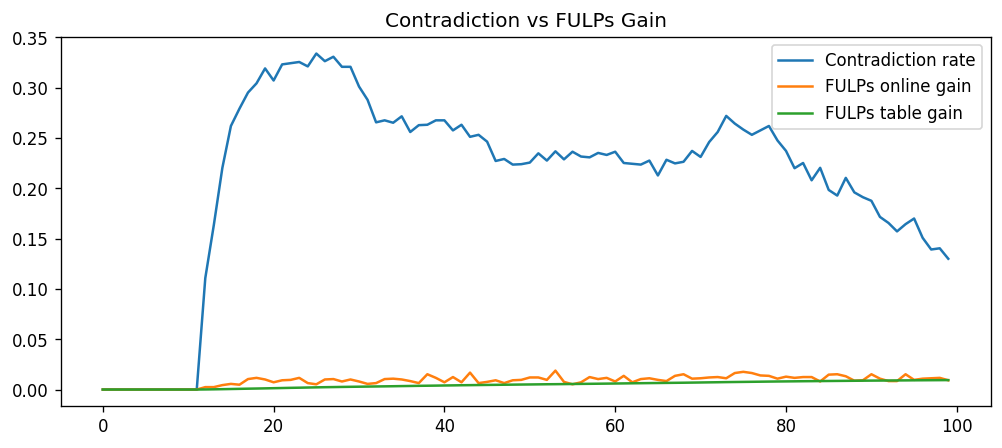

In [ ]:
# ── Cell 16: Contradiction Diagnostics ─────────────────────────────────────────
contra = np.array(single_history['contra_rate'])

delta_online = np.array(single_history['fulps_online_acc']) - np.array(single_history['base_online_acc'])
delta_table  = np.array(single_history['fulps_table_acc'])  - np.array(single_history['base_table_acc'])

corr_online = np.corrcoef(contra, delta_online)[0,1]
corr_table  = np.corrcoef(contra, delta_table)[0,1]

print(f"Corr(contradiction, online gain) = {corr_online:.4f}")
print(f"Corr(contradiction, table gain)  = {corr_table:.4f}")

plt.figure(figsize=(10,4))
plt.plot(contra, label='Contradiction rate')
plt.plot(delta_online, label='FULPs online gain')
plt.plot(delta_table, label='FULPs table gain')
plt.legend()
plt.title("Contradiction vs FULPs Gain")
plt.show()